必要ライブラリのインストール

In [76]:
import sys
import pandas as pd
import numpy as np
from sklearn import svm
import scipy.stats
import matplotlib.pyplot as plt
import csv
import re
from sklearn.svm import OneClassSVM
from sklearn.preprocessing import StandardScaler
from scipy import stats
from sklearn import preprocessing
import datetime
from dfply import *
import random
import gc
import shap
plt.style.use('ggplot')
# pd.options.display.float_format = '{:.2f}'.format

生データの読み込み

ECDISデータの読み込み

In [77]:
raw_data_ECDIS = pd.read_csv('../data/ECDIS__FMD-3x00.csv', header=0, delimiter=',',dtype = {"equipment_label_no":"object","f_shipno":"object"})

raw_data_ECDIS = raw_data_ECDIS >> mutate(id = X.f_shipno+"-"+X.equipment_label_no,
                         measurement_ymd = X.measurement_date.str[:10],
                         measurement_ymd_h = X.measurement_date.str[11:13]) >> mutate(
    measurement_ymd_hms = X.measurement_ymd+" "+X.measurement_ymd_h+":00:00")

C:\Users\小山佳祐\AppData\Local\Temp\ipykernel_19560\2712817729.py:1: DtypeWarning: Columns (11,12,13,14,15,16,22,26,27,28,29,31,32,33,39,43,44,45,51,55,58,91,92,93,94,95,97,99,100,102,103,104,105,106,107,108,109,110,111,113,115,116,118,119,120,121,122,123,124,125,126,127,129,131,132,134,135,136,137,138) have mixed types. Specify dtype option on import or set low_memory=False.
  raw_data_ECDIS = pd.read_csv('../data/ECDIS__FMD-3x00.csv', header=0, delimiter=',',dtype = {"equipment_label_no":"object","f_shipno":"object"})


Radarデータの読み込み

In [78]:
raw_data_Radar= pd.read_csv('../data/Radar__FAR-3xx0.csv', header=0, delimiter=',',dtype = {"equipment_label_no":"object","f_shipno":"object"})
raw_data_Radar = raw_data_Radar>> mutate(id = X.f_shipno+"-"+X.equipment_label_no,
                         measurement_ymd = X.measurement_date.str[:10],
                         measurement_ymd_h = X.measurement_date.str[11:13]) >> mutate(
    measurement_ymd_hms = X.measurement_ymd+" "+X.measurement_ymd_h+":00:00")

C:\Users\小山佳祐\AppData\Local\Temp\ipykernel_19560\642471685.py:1: DtypeWarning: Columns (57,58,59,60,61,62,63,64,65,66,70,71,72,73,74,75,76,77,78,79,99,101,105,171,173,174,175,176,179,180,198,199,202,204,244,245,246,247,249,250,251,255,256,257,258,259,260,264,265,266,267,268,269) have mixed types. Specify dtype option on import or set low_memory=False.
  raw_data_Radar= pd.read_csv('../data/Radar__FAR-3xx0.csv', header=0, delimiter=',',dtype = {"equipment_label_no":"object","f_shipno":"object"})


必要なカラムを抽出、および半角処理

In [79]:
raw_data_ECDIS_select = raw_data_ECDIS[["id","equipment_label_no","f_shipno","measurement_date"
                                        ,"processor_unit_units_hardware_info__serial_number_cpu_bd","monitor1_units__unit","monitor2_units__unit"
                                        ,"measurement_ymd","measurement_ymd_h","measurement_ymd_hms"
                                        ,"monitor1_units_status_main__temp","monitor1_units_status_main__fan1"
                                        ,"monitor1_units_status_main__fan2","monitor1_units_status_main__fan3"
                                        ,"monitor2_units_status_main__temp","monitor2_units_status_main__fan1"
                                        ,"monitor2_units_status_main__fan2","monitor2_units_status_main__fan3","processor_unit_units_status_cpu_board__cpu_fan"
                                        ,"processor_unit_units_status_cpu_board__cpu_bd_temp","processor_unit_units_status_cpu_board__cpu_core_temp"
                                        ,"processor_unit_units_status_cpu_board__gpu_core_temp","processor_unit_units_status_cpu_board__remote1_temp"
                                        ,"processor_unit_units_status_cpu_board__remote2_temp","processor_unit_units_status_cpu_board__cpu_core_vol"
                                        ,"processor_unit_units_status_cpu_board__cpu_bd_vbat","processor_unit_units_status_cpu_board__cpu_bd_p3_3v"
                                        ,"processor_unit_units_status_cpu_board__cpu_bd_p5v","processor_unit_units_status_cpu_board__cpu_bd_p12v"
                                        ,"processor_unit_units_status_cpu_board__cpu_bd_fan1","processor_unit_units_status_cpu_board__cpu_bd_fan2"
                                        ,"processor_unit_units_status_boot_device__wearout_ind"]]


data_ECDIS=raw_data_ECDIS_select.rename(columns={"processor_unit_units_hardware_info__serial_number_cpu_bd":"processor_unit_units_hardware_info_serial_number_cpu_bd"
                                                 ,"monitor1_units__unit":"monitor1_units_unit"
                                                 ,"monitor2_units__unit":"monitor2_units_unit"
                                                 ,"monitor1_units_status_main__temp":"monitor1_units_status_main_temp"
                                                 ,"monitor1_units_status_main__fan1":"monitor1_units_status_main_fan1"
                                                 ,"monitor1_units_status_main__fan2":"monitor1_units_status_main_fan2"
                                                 ,"monitor1_units_status_main__fan3":"monitor1_units_status_main_fan3"
                                                 ,"monitor2_units_status_main__temp":"monitor2_units_status_main_temp"
                                                 ,"monitor2_units_status_main__fan1":"monitor2_units_status_main_fan1"
                                                 ,"monitor2_units_status_main__fan2":"monitor2_units_status_main_fan2"
                                                 ,"monitor2_units_status_main__fan3":"monitor2_units_status_main_fan3"
                                                 ,"processor_unit_units_status_cpu_board__cpu_fan":"processor_unit_units_status_cpu_board_cpu_fan"
                                                 ,"processor_unit_units_status_cpu_board__cpu_bd_temp":"processor_unit_units_status_cpu_board_cpu_bd_temp"
                                                 ,"processor_unit_units_status_cpu_board__cpu_core_temp":"processor_unit_units_status_cpu_board_cpu_core_temp"
                                                 ,"processor_unit_units_status_cpu_board__gpu_core_temp":"processor_unit_units_status_cpu_board_gpu_core_temp"
                                                 ,"processor_unit_units_status_cpu_board__remote1_temp":"processor_unit_units_status_cpu_board_remote1_temp"
                                                 ,"processor_unit_units_status_cpu_board__remote2_temp":"processor_unit_units_status_cpu_board_remote2_temp"
                                                 ,"processor_unit_units_status_cpu_board__cpu_core_vol":"processor_unit_units_status_cpu_board_cpu_core_vol"
                                                 ,"processor_unit_units_status_cpu_board__cpu_bd_vbat":"processor_unit_units_status_cpu_board_cpu_bd_vbat"
                                                 ,"processor_unit_units_status_cpu_board__cpu_bd_p3_3v":"processor_unit_units_status_cpu_board_cpu_bd_p3_3v"
                                                 ,"processor_unit_units_status_cpu_board__cpu_bd_p5v":"processor_unit_units_status_cpu_board_cpu_bd_p5v"
                                                 ,"processor_unit_units_status_cpu_board__cpu_bd_p12v":"processor_unit_units_status_cpu_board_cpu_bd_p12v"
                                                 ,"processor_unit_units_status_cpu_board__cpu_bd_fan1":"processor_unit_units_status_cpu_board_cpu_bd_fan1"
                                                 ,"processor_unit_units_status_cpu_board__cpu_bd_fan2":"processor_unit_units_status_cpu_board_cpu_bd_fan2"
                                                 ,"processor_unit_units_status_boot_device__wearout_ind":"processor_unit_units_status_boot_device_wearout_ind"
                                                })

In [80]:
data_Radar = raw_data_Radar[["id","equipment_label_no","f_shipno","measurement_date",
                             "processor_unit_units_hardware_info_serial_number_cpu_bd","monitor1_units_unit","monitor2_units_unit",
                             "measurement_ymd","measurement_ymd_h","measurement_ymd_hms",
                             "monitor1_units_status_main_temp","monitor1_units_status_main_fan1",
                            "monitor1_units_status_main_fan2","monitor1_units_status_main_fan3"
                             ,"monitor2_units_status_main_temp"
                             ,"monitor2_units_status_main_fan1","monitor2_units_status_main_fan2"
                             ,"monitor2_units_status_main_fan3","processor_unit_units_status_cpu_board_cpu_fan",
                            "processor_unit_units_status_cpu_board_cpu_bd_temp","processor_unit_units_status_cpu_board_cpu_core_temp",
                            "processor_unit_units_status_cpu_board_gpu_core_temp","processor_unit_units_status_cpu_board_remote1_temp",
                            "processor_unit_units_status_cpu_board_remote2_temp","processor_unit_units_status_cpu_board_cpu_core_vol",
                            "processor_unit_units_status_cpu_board_cpu_bd_vbat","processor_unit_units_status_cpu_board_cpu_bd_p3_3v",
                            "processor_unit_units_status_cpu_board_cpu_bd_p5v","processor_unit_units_status_cpu_board_cpu_bd_p12v",
                            "processor_unit_units_status_cpu_board_cpu_bd_fan1","processor_unit_units_status_cpu_board_cpu_bd_fan2",
                            "processor_unit_units_status_storage_device_wearout_ind"]]

カラムの説明

ここでデータのカラム値は以下の通りである。
カラム名	説明

id	                                                船舶番号 (f_shipno) と装置ラベル番号 (equipment_label_no) を結合したもの（ユニークID）

equipment_label_no	                                装置ラベル番号

f_shipno	                                        船舶番号

measurement_date	                                測定日時

processor_unit_units_hardware_info_serial_number_cpu_bd	CPUボードのシリアル番号

monitor1_units_unit	                                モニター1のユニット情報

monitor2_units_unit	                                モニター2のユニット情報

measurement_ymd	                                    測定日の年月日部分（YYYY-MM-DD）

measurement_ymd_h	                                測定日の時間部分（HH）

measurement_ymd_hms	                                測定日の詳細な日時（YYYY-MM-DD HH:00:00）

monitor1_units_status_main_temp	                    モニター1のメインステータスの温度

monitor1_units_status_main_fan1	                    モニター1のメインステータスのファン1

monitor1_units_status_main_fan2	                    モニター1のメインステータスのファン2

monitor1_units_status_main_fan3	                    モニター1のメインステータスのファン3

monitor2_units_status_main_temp	                    モニター2のメインステータスの温度

monitor2_units_status_main_fan1	                    モニター2のメインステータスのファン1

monitor2_units_status_main_fan2	                    モニター2のメインステータスのファン2

monitor2_units_status_main_fan3	                    モニター2のメインステータスのファン3

processor_unit_units_status_cpu_board_cpu_fan	    CPUボードのCPUファンステータス

processor_unit_units_status_cpu_board_cpu_bd_temp	CPUボードの温度

processor_unit_units_status_cpu_board_cpu_core_temp	CPUコアの温度

processor_unit_units_status_cpu_board_gpu_core_temp	GPUコアの温度

processor_unit_units_status_cpu_board_remote1_temp	リモート1の温度

processor_unit_units_status_cpu_board_remote2_temp	リモート2の温度

processor_unit_units_status_cpu_board_cpu_core_vol	CPUコアの電圧

processor_unit_units_status_cpu_board_cpu_bd_vbat	CPUボードのバッテリ電圧

processor_unit_units_status_cpu_board_cpu_bd_p3_3v	CPUボードの3.3V電源

processor_unit_units_status_cpu_board_cpu_bd_p5v	CPUボードの5V電源

processor_unit_units_status_cpu_board_cpu_bd_p12v	CPUボードの12V電源

processor_unit_units_status_cpu_board_cpu_bd_fan1	CPUボードのファン1

processor_unit_units_status_cpu_board_cpu_bd_fan2	CPUボードのファン2

processor_unit_units_status_boot_device_wearout_ind	起動デバイスの摩耗インデックス

データの結合

In [81]:
con=pd.concat([data_Radar, data_ECDIS])
data_con=con

キャッシュの削除

In [82]:
del raw_data_ECDIS
del raw_data_Radar
gc.collect()

14644

データの確認

なお、「f_shipno」は船舶番号、「equipment_label_no」は装置ラベル番号、「id」は船舶番号と装置ラベル番号を結合したもので装置を特定する。

In [83]:
print("ECDIS&Radar")
print("idユニーク数                :",len(data_con["id"].unique()))
print("f_shipnoユニーク数          :",len(data_con["f_shipno"].unique()))
print("equipment_label_noユニーク数:",len(data_con["equipment_label_no"].unique()),"\n")

ECDIS&Radar
idユニーク数                : 367
f_shipnoユニーク数          : 114
equipment_label_noユニーク数: 367 



In [84]:
# raw_data.shape
print("行数: "+str(data_con.shape[0]))
print("列数: "+str(data_con.shape[1]))
#データ期間
print("データ開始日時: "+str(data_con["measurement_date"].min()))
print("データ終了日時: "+str(data_con["measurement_date"].max()))
print("f_shipno(ユニーク数): "+str(data_con["f_shipno"].nunique()))
print("equipment_label_no(ユニーク数): "+str(data_con["equipment_label_no"].nunique()))

行数: 2339341
列数: 33
データ開始日時: 2014-10-10 09:00:01
データ終了日時: 2021-04-20 23:34:16
f_shipno(ユニーク数): 114
equipment_label_no(ユニーク数): 367


日付のフォーマットの変更

In [85]:
data_con["measurement_ymd_hms"] = pd.to_datetime(data_con["measurement_ymd_hms"], format='%Y-%m-%d %H:%M:%S')

データの加工

・一時間に一個のデータしか用いない（最初のデータ）

・一日取得データ数１５件以上のみ使用

In [86]:
# 1時間に1データに変更
data_con["measurement_date"] = pd.to_datetime(data_con["measurement_date"], format='%Y-%m-%d %H:%M:%S')

data_con["order"] = data_con.groupby(["id", "measurement_ymd", "measurement_ymd_h"])["measurement_date"].rank()

modified_data = data_con[data_con["order"]==1]

In [87]:
check_day_cnt = modified_data.groupby(["id", "measurement_ymd"]).agg({"measurement_date":"nunique"}).assign(
    min_measurement_date = modified_data.groupby(['id', "measurement_ymd"]).agg({"measurement_date":"min"}),
    max_measurement_date = modified_data.groupby(['id', "measurement_ymd"]).agg({"measurement_date":"max"})).reset_index()

check_day_cnt["id_date"] = check_day_cnt["id"]+"-"+check_day_cnt["measurement_ymd"]

check_day_cnt = check_day_cnt.rename(columns={"measurement_date":"cnt"})

target_id_date = check_day_cnt[check_day_cnt["cnt"] >= 15]["id_date"]

条件２の適用

In [88]:
modified_data["tag"] = modified_data["id"]+"-"+modified_data["measurement_ymd"]
# modified_data.head()

final_data = modified_data[modified_data["tag"].isin(target_id_date)]
final_data.shape

C:\Users\小山佳祐\AppData\Local\Temp\ipykernel_19560\3394232165.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  modified_data["tag"] = modified_data["id"]+"-"+modified_data["measurement_ymd"]


(2275886, 35)

ここまでが生データに対する処理である

データは：final_dataである

以下では、発見されている異常データのインスタンスを含むようなデータを抽出する

cpuのシリアル番号によって分類されるADP555を抜き出す

In [89]:
(final_data["processor_unit_units_hardware_info_serial_number_cpu_bd"].str[1:3]).unique()

array(['19', '17', '18', '16', '20', '13', '15', '14'], dtype=object)

In [90]:
data_ADP555 = final_data[((final_data["processor_unit_units_hardware_info_serial_number_cpu_bd"].str[1:3])
                          .isin(["16","15","14","13"]))]


データの確認

In [91]:
data_ADP555["measurement_date"].describe()

count                           544452
mean     2018-12-11 05:24:57.599845120
min                2014-10-10 09:00:01
25%                2018-01-21 03:45:02
50%                2019-01-15 18:00:02
75%                2020-03-10 03:00:02
max                2021-04-20 23:00:02
Name: measurement_date, dtype: object

異常データの確認

今回確認されている異常データは

id = "9748019T-323"で確認された

2028/08/15付近の

processor_unit_units_status_cpu_board_cpu_bd_fan2

から確認されるものである

C:\Users\小山佳祐\AppData\Local\Temp\ipykernel_19560\3095729930.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax1.legend()


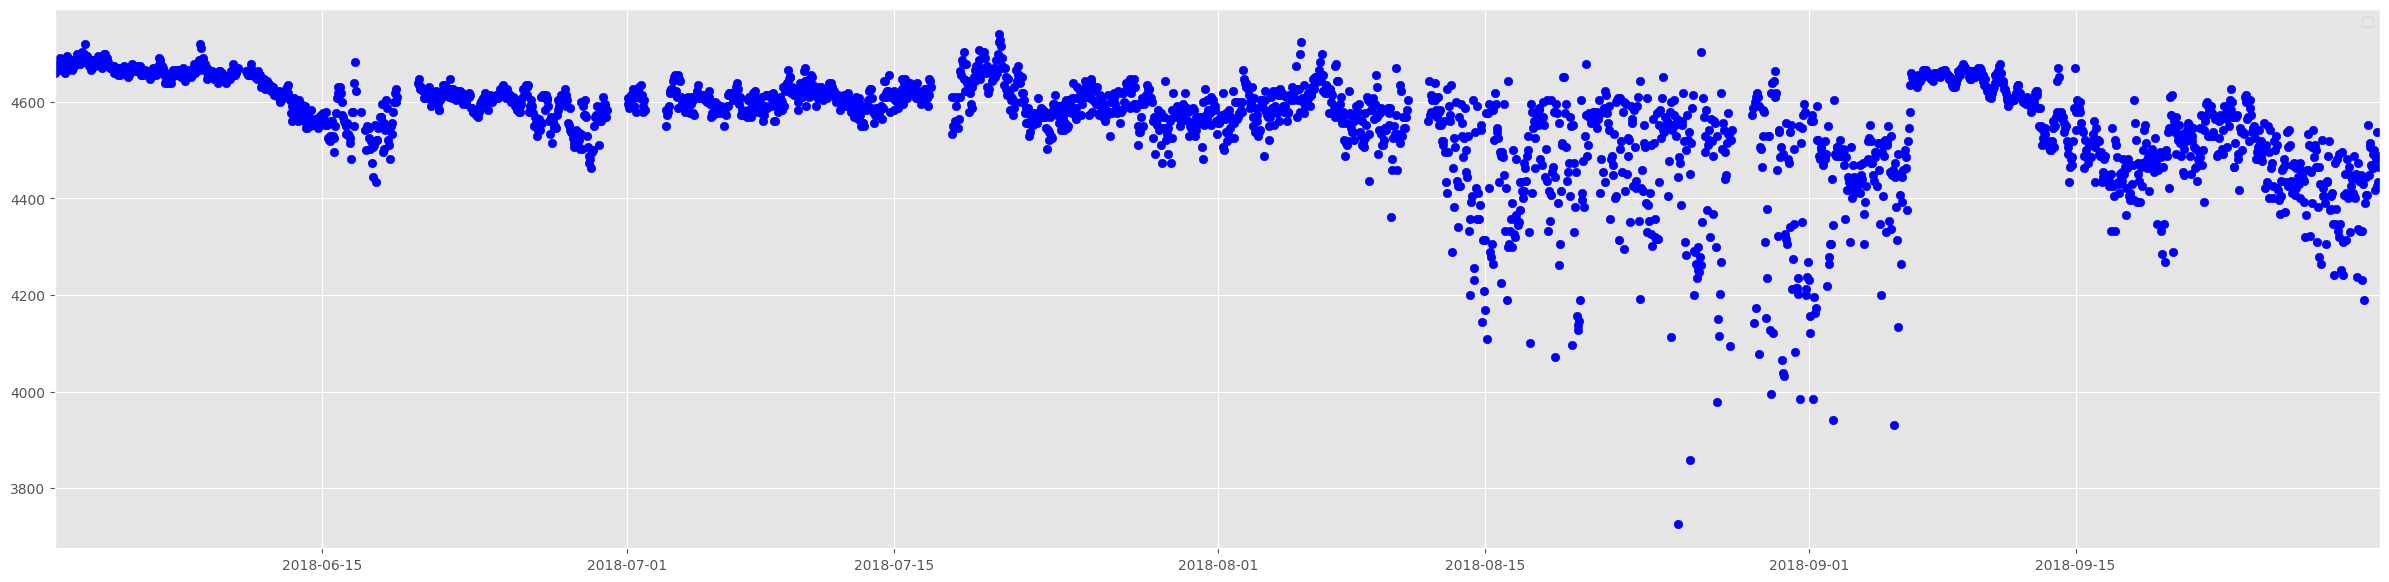

In [92]:
#期間始め
s_day = pd.to_datetime("2018/06/01 00:00:00", format='%Y/%m/%d %H:%M:%S')
#期間終わり
e_day=pd.to_datetime("2018/10/1 00:00:00", format='%Y/%m/%d %H:%M:%S')

#特定データの抜き出し
ab_date=data_ADP555[data_ADP555["id"]=="9748019T-325"]

test_select_df = ab_date[(ab_date["measurement_date"]>=s_day)&(ab_date["measurement_date"]<e_day)]


time = pd.to_datetime(test_select_df["measurement_date"], format='%Y/%m/%d %H:%M:%S')


fig = plt.figure(figsize=(30,7))
ax1 = fig.add_subplot(1,1,1)
ax1.scatter(time,test_select_df["processor_unit_units_status_cpu_board_cpu_bd_fan2"], color='blue')
ax1.set_xlim(time.min(),time.max())
ax1.legend()

以下の実装では、上記の異常データを発見するとともに、異常の原因をその特徴量であると発見し、さらに予兆を検知できるようなモデルを作成することを目標とする

異常を含むidのデータセットを作成

すなわち特定の機器に対してモデルを作成する

In [93]:
data_model=data_ADP555[data_ADP555["id"]=="9748019T-325"]
colums_list=["processor_unit_units_status_cpu_board_cpu_fan","processor_unit_units_status_cpu_board_cpu_bd_fan1"
             ,"processor_unit_units_status_cpu_board_cpu_bd_fan2","processor_unit_units_status_cpu_board_cpu_bd_temp"
             ,"processor_unit_units_status_cpu_board_cpu_core_temp","processor_unit_units_status_cpu_board_gpu_core_temp"
             ,"processor_unit_units_status_cpu_board_cpu_core_vol","processor_unit_units_status_cpu_board_cpu_bd_vbat"
             ,"processor_unit_units_status_cpu_board_cpu_bd_p3_3v","processor_unit_units_status_cpu_board_cpu_bd_p5v"
             ,"processor_unit_units_status_cpu_board_cpu_bd_p12v"]

異常検知に用いられるカラムは以下の通り

カラム名	説明

processor_unit_units_status_cpu_board_cpu_fan	CPUボードのCPUファンのステータス

processor_unit_units_status_cpu_board_cpu_bd_fan1	CPUボードのファン1のステータス

processor_unit_units_status_cpu_board_cpu_bd_fan2	CPUボードのファン2のステータス

processor_unit_units_status_cpu_board_cpu_bd_temp	CPUボードの温度

processor_unit_units_status_cpu_board_cpu_core_temp	CPUコアの温度

processor_unit_units_status_cpu_board_gpu_core_temp	GPUコアの温度

processor_unit_units_status_cpu_board_cpu_core_vol	CPUコアの電圧

processor_unit_units_status_cpu_board_cpu_bd_vbat	CPUボードのバッテリ電圧

processor_unit_units_status_cpu_board_cpu_bd_p3_3v	CPUボードの3.3V電源

processor_unit_units_status_cpu_board_cpu_bd_p5v	CPUボードの5V電源

processor_unit_units_status_cpu_board_cpu_bd_p12v	CPUボードの12V電源



In [94]:
data_model


,id,equipment_label_no,f_shipno,measurement_date,processor_unit_units_hardware_info_serial_number_cpu_bd,monitor1_units_unit,monitor2_units_unit,measurement_ymd,measurement_ymd_h,measurement_ymd_hms,...,processor_unit_units_status_cpu_board_cpu_bd_vbat,processor_unit_units_status_cpu_board_cpu_bd_p3_3v,processor_unit_units_status_cpu_board_cpu_bd_p5v,processor_unit_units_status_cpu_board_cpu_bd_p12v,processor_unit_units_status_cpu_board_cpu_bd_fan1,processor_unit_units_status_cpu_board_cpu_bd_fan2,processor_unit_units_status_storage_device_wearout_ind,processor_unit_units_status_boot_device_wearout_ind,order,tag
1038152,9748019T-325,325,9748019T,2015-12-22 06:15:00,O14K5041,MU-190,MU-190,2015-12-22,06,2015-12-22 06:00:00,...,3.711,3.420,5.120,11.874,4599.0,4724.0,NaN,NaN,1.0,9748019T-325-2015-12-22
1038154,9748019T-325,325,9748019T,2015-12-22 07:00:02,O14K5041,MU-190,MU-190,2015-12-22,07,2015-12-22 07:00:00,...,3.704,3.420,5.120,11.859,4611.0,4736.0,NaN,NaN,1.0,9748019T-325-2015-12-22
1038155,9748019T-325,325,9748019T,2015-12-22 08:00:03,O14K5041,MU-190,MU-190,2015-12-22,08,2015-12-22 08:00:00,...,3.704,3.424,5.120,11.874,4599.0,4753.0,NaN,NaN,1.0,9748019T-325-2015-12-22
1038156,9748019T-325,325,9748019T,2015-12-22 09:00:03,O14K5041,MU-190,MU-190,2015-12-22,09,2015-12-22 09:00:00,...,3.704,3.420,5.120,11.874,4599.0,4749.0,NaN,NaN,1.0,9748019T-325-2015-12-22
1038157,9748019T-325,325,9748019T,2015-12-22 10:00:03,O14K5041,MU-190,MU-190,2015-12-22,10,2015-12-22 10:00:00,...,3.711,3.420,5.128,11.874,4587.0,4749.0,NaN,NaN,1.0,9748019T-325-2015-12-22
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1064736,9748019T-325,325,9748019T,2019-02-04 19:00:02,O14K5041,NaN,NaN,2019-02-04,19,2019-02-04 19:00:00,...,3.698,3.420,5.130,12.063,4572.0,4481.0,NaN,NaN,1.0,9748019T-325-2019-02-04
1064737,9748019T-325,325,9748019T,2019-02-04 20:00:02,O14K5041,NaN,NaN,2019-02-04,20,2019-02-04 20:00:00,...,3.698,3.403,5.130,12.063,4572.0,4599.0,NaN,NaN,1.0,9748019T-325-2019-02-04
1064738,9748019T-325,325,9748019T,2019-02-04 21:00:02,O14K5041,NaN,NaN,2019-02-04,21,2019-02-04 21:00:00,...,3.698,3.420,5.130,12.063,4560.0,4568.0,NaN,NaN,1.0,9748019T-325-2019-02-04
1064739,9748019T-325,325,9748019T,2019-02-04 22:00:02,O14K5041,NaN,NaN,2019-02-04,22,2019-02-04 22:00:00,...,3.698,3.420,5.130,12.063,4572.0,4522.0,NaN,NaN,1.0,9748019T-325-2019-02-04


実験条件の整理

今、データは39か月存在している。

１か月のデータを直近２年のデータを使用して予測を行うので
合計15回実験を行う

以下、autoencoderの実装を行う

まずはデータの準備から

In [95]:
#データの標準化（０～１にする）
scaler = preprocessing.MinMaxScaler()
data_model[colums_list] = scaler.fit_transform(data_model[colums_list])
data_model[colums_list] += 0.00001

# 保存先
ans_data=pd.DataFrame()

#実装に必要なカラムと取得日時のカラムの作成
data_ex = data_model[colums_list+["measurement_date"]]

#欠損値処理（欠損値があった場合は落とす）
data_ex=data_ex.dropna(how='any')
data_ex=data_ex.reset_index(drop = True)
data_ex["measurement_date"]=pd.to_datetime(data_ex["measurement_date"], format='%Y/%m/%d %H:%M:%S')


#初期データの抜き出し及び、繰り返し処理の準備
data_trainestart = data_ex["measurement_date"][0]
data_trainestart_year = data_trainestart.year
data_trainestart_month = data_trainestart.month
data_trainestart = str(data_trainestart_year) + "/" + str(data_trainestart_month) + "/01 00:00:00"

data_trainend_year = data_trainestart_year + 2
data_trainend_month = data_trainestart_month
data_trainend = str(data_trainend_year) + "/" + str(data_trainend_month) + "/01 00:00:00"

data_teststart = data_trainend
if data_trainend_month == 12:
    data_testend_year = data_trainend_year + 1
    data_testend_month = 1
else:
    data_testend_year = data_trainend_year
    data_testend_month = data_trainend_month + 1

data_testend = str(data_testend_year) + "/" + str(data_testend_month) + "/01 00:00:00"

print("初期データ(train)日付はじまり: "+ str(data_trainestart))
print("初期データ(train)日付終わり: "+str(data_trainend))

print("初期データ(test)日付はじまり: "+ str(data_teststart))
print("初期データ(test)日付終わり: "+str(data_testend))



#繰り返し回数
num = 15


初期データ(train)日付はじまり: 2015/12/01 00:00:00
初期データ(train)日付終わり: 2017/12/01 00:00:00
初期データ(test)日付はじまり: 2017/12/01 00:00:00
初期データ(test)日付終わり: 2018/1/01 00:00:00


C:\Users\小山佳祐\AppData\Local\Temp\ipykernel_19560\1439811388.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_model[colums_list] = scaler.fit_transform(data_model[colums_list])
C:\Users\小山佳祐\AppData\Local\Temp\ipykernel_19560\1439811388.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_model[colums_list] += 0.00001


In [96]:
data_ex.columns

Index(['processor_unit_units_status_cpu_board_cpu_fan',
       'processor_unit_units_status_cpu_board_cpu_bd_fan1',
       'processor_unit_units_status_cpu_board_cpu_bd_fan2',
       'processor_unit_units_status_cpu_board_cpu_bd_temp',
       'processor_unit_units_status_cpu_board_cpu_core_temp',
       'processor_unit_units_status_cpu_board_gpu_core_temp',
       'processor_unit_units_status_cpu_board_cpu_core_vol',
       'processor_unit_units_status_cpu_board_cpu_bd_vbat',
       'processor_unit_units_status_cpu_board_cpu_bd_p3_3v',
       'processor_unit_units_status_cpu_board_cpu_bd_p5v',
       'processor_unit_units_status_cpu_board_cpu_bd_p12v',
       'measurement_date'],
      dtype='object')

ここからモデル作成に入る

In [97]:
#必要ライブラリのインストール

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import setuptools
import tensorflow as tf
from tensorflow import keras

from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.model_selection import train_test_split
from tensorflow.keras import layers, losses
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Model

モデルの準備

今回はkerasのsequentialを用いてモデルを作成する

ハイパーパラメータについて

１，中間層のユニット数

２，中間層の活性化関数

３，出力層の活性化関数

４，モデルの最適化手法

５，モデルの最小化関数

６，異常スコアの関数

７，閾値

８，エポック数

自作損失関数の定義

In [1]:
# カスタム損失関数の定義
def custom_loss(delta):
    def loss(y_true, y_pred):
        error = tf.abs(y_true - y_pred)
        small_error_loss = tf.square(error)
        large_error_loss = error
        return tf.where(error < delta, large_error_loss, small_error_loss)
    return loss

In [109]:
# モデルを作成
model = keras.Sequential(name="autoencoder")

#入力層の情報
input_unit = 11

#中間層の情報
middle_unit = 8

#出力層の情報
output_unit = 11

#層の追加
#中間層の作成
model.add(layers.Dense(units=middle_unit, activation="relu" ,input_shape=(input_unit,)))

#出力層の柵瀬
model.add(layers.Dense(units=output_unit, activation="sigmoid"))

#モデルの構造を確認する
print(model.summary())

#モデルのコンパイル
model.compile(optimizer="adam", loss=custom_loss(delta=0.5))

#閾値の設定
threshold = 0.8

c:\Users\小山佳祐\Desktop\研究元ファイル\abnormal\research_abnormal\venv\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 8)              │            96 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 11)             │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 195 (780.00 B)

 Trainable params: 195 (780.00 B)

 Non-trainable params: 0 (0.00 B)

None


元データと出力データの差を計算する関数

In [99]:
#二乗誤差を取るだけ
#大きいほど元のデータと離れているので異常
def abnomalScores(originalDF,reduceDF):
  loss = np.sum((np.array(originalDF)-np.array(reduceDF))**2,axis=1)
  loss = pd.Series(data=loss,index=originalDF.index)
  loss = (loss-np.min(loss))/(np.max(loss)-np.min(loss))
  return loss

モデルの実装部分

In [110]:
#結果（日付と異常値スコアを含む配列の準備）
# 空のデータフレームを作成
results_df = pd.DataFrame(columns=["measurement_date", "anomaly_score"])
abnormal_df = pd.DataFrame(columns=["measurement_date", "anomaly_score"])

#初期データの抜き出し及び、繰り返し処理の準備
data_trainestart = data_ex["measurement_date"][0]
data_trainestart_year = data_trainestart.year
data_trainestart_month = data_trainestart.month
data_trainestart = str(data_trainestart_year) + "/" + str(data_trainestart_month) + "/01 00:00:00"

data_trainend_year = data_trainestart_year + 2
data_trainend_month = data_trainestart_month
data_trainend = str(data_trainend_year) + "/" + str(data_trainend_month) + "/01 00:00:00"

data_teststart = data_trainend
if data_trainend_month == 12:
    data_testend_year = data_trainend_year + 1
    data_testend_month = 1
else:
    data_testend_year = data_trainend_year
    data_testend_month = data_trainend_month + 1

data_testend = str(data_testend_year) + "/" + str(data_testend_month) + "/01 00:00:00"


#モデル実装部分
for i in range(num):
    print("============================================")
    print(str(i+1) + "回目のモデル")
    #i回目のデータの抜き出し

    #トレーニングデータの抜き出し
    train_data = data_ex[(data_ex["measurement_date"]<data_trainend) & (data_ex["measurement_date"]>=data_trainestart)]
    train_data = train_data[colums_list]
    train_data = train_data.values


    #初期データの抜き出し及び、繰り返し処理の準備
    #data_trainestart = data_ex["measurement_date"][0]
    #data_trainend_year = data_trainestart.year + 2
    #data_trainend_month = data_trainestart.month
    #data_trainend = str(data_trainend_year) + "/" + str(data_trainend_month) + "/01 00:00:00"

    #テストデータの抜き出し
    #テストデータはdata_trainendの一か月である
    test_data = data_ex[(data_ex["measurement_date"]<data_testend) & (data_ex["measurement_date"]>=data_teststart)]
    test_data_origin = data_ex[(data_ex["measurement_date"]<data_testend) & (data_ex["measurement_date"]>=data_teststart)]
    test_data = test_data[colums_list]
    test_data = test_data.values

    #該当データ期間
    print("はじまり(train)" + str(data_trainestart))
    print("終わり(train)" + str(data_trainend))
    print("はじまり(test)" + str(data_teststart))
    print("終わり(test)" + str(data_testend))


    #モデルの学習
    model.fit(train_data, train_data,
                epochs=5,
                shuffle=True,
                validation_data=(train_data, train_data))
    
    #結果
    result_data = model.predict(test_data)

    #pandas形式へ変換
    test_data = pd.DataFrame(test_data,columns=colums_list)
    print(len(test_data))
    result_data = pd.DataFrame(result_data,columns=colums_list)

    #異常値の算出
    abnormal_value = abnomalScores(test_data,result_data)



    #結果の格納
    temp_df = pd.DataFrame({
        "measurement_date": test_data_origin["measurement_date"].values,
        "anomaly_score": abnormal_value
    })

    results_df = pd.concat([results_df, temp_df], ignore_index=True)

    #異常値のみの格納
    for i in range(len(abnormal_value)):
        if abnormal_value[i] > threshold:
            # 1行のデータフレームを作成
            tempab_df = pd.DataFrame({
                "measurement_date": [test_data_origin["measurement_date"].iloc[i]],
                "anomaly_score": [abnormal_value[i]]
            })
    
            # 異常値のみを格納するデータフレームに追加
            abnormal_df = pd.concat([abnormal_df, tempab_df], ignore_index=True)



    


    #日付の更新
    if data_trainestart_month == 12:
        data_trainestart_year += 1
        data_trainestart_month = 1
    else:
        data_trainestart_month += 1
    data_trainestart = str(data_trainestart_year) + "/" + str(data_trainestart_month) + "/01 00:00:00"        
    
    data_trainend_year = data_trainestart_year + 2
    data_trainend_month = data_trainestart_month
    data_trainend = str(data_trainend_year) + "/" + str(data_trainend_month) + "/01 00:00:00"

    data_teststart = data_trainend
    if data_trainend_month == 12:
        data_testend_year = data_trainend_year + 1
        data_testend_month = 1
    else:
        data_testend_year = data_trainend_year
        data_testend_month = data_trainend_month + 1

    data_testend = str(data_testend_year) + "/" + str(data_testend_month) + "/01 00:00:00"

print(results_df)
print(abnormal_df)


    

1回目のモデル
はじまり(train)2015/12/01 00:00:00
終わり(train)2017/12/01 00:00:00
はじまり(test)2017/12/01 00:00:00
終わり(test)2018/1/01 00:00:00
Epoch 1/5
519/519 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.6278 - val_loss: 0.5088
Epoch 2/5
519/519 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4986 - val_loss: 0.4805
Epoch 3/5
519/519 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.4767 - val_loss: 0.4673
Epoch 4/5
519/519 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.4649 - val_loss: 0.4602
Epoch 5/5
519/519 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.4586 - val_loss: 0.4547
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
740
2回目のモデル
はじまり(train)2016/1/01 00:00:00
終わり(train)2018/1/01 00:00:00
はじまり(test)2018/1/01 00:00:00
終わり(test)2018/2/01 00:00:00
Epoch 1/5
 29/536 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4556  

C:\Users\小山佳祐\AppData\Local\Temp\ipykernel_19560\3443091316.py:84: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  results_df = pd.concat([results_df, temp_df], ignore_index=True)
C:\Users\小山佳祐\AppData\Local\Temp\ipykernel_19560\3443091316.py:96: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  abnormal_df = pd.concat([abnormal_df, tempab_df], ignore_index=True)


536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.4516 - val_loss: 0.4496
Epoch 2/5
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.4494 - val_loss: 0.4488
Epoch 3/5
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.4489 - val_loss: 0.4485
Epoch 4/5
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.4486 - val_loss: 0.4483
Epoch 5/5
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.4482 - val_loss: 0.4481
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
744
3回目のモデル
はじまり(train)2016/2/01 00:00:00
終わり(train)2018/2/01 00:00:00
はじまり(test)2018/2/01 00:00:00
終わり(test)2018/3/01 00:00:00
Epoch 1/5
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.4451 - val_loss: 0.4454
Epoch 2/5
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.4450 - val_loss: 0.4452
Epoch 3/5
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.4450 - val_loss: 0.4450
Epoch 4/5
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.4449 - val_loss: 0.4448
Epoch 5/5
536/536 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.4446 - val_loss: 

散布図の作成

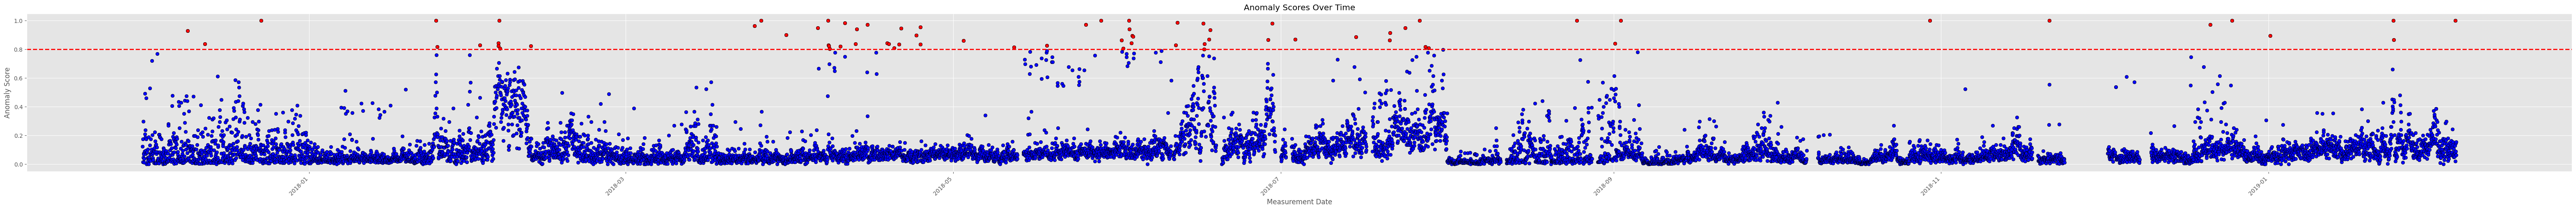

In [111]:

# 散布図の作成
plt.figure(figsize=(80, 5))
plt.scatter(results_df["measurement_date"], results_df["anomaly_score"], c='blue', marker='o', edgecolor='k')
#異常スコアを赤で表示する
plt.scatter(abnormal_df["measurement_date"], abnormal_df["anomaly_score"], c='red', marker='o', edgecolor='k')

# y=0.8の位置に赤い横線を引く
plt.axhline(y=0.8, color='red', linestyle='--', linewidth=2)

# グラフのタイトルとラベル
plt.title('Anomaly Scores Over Time')
plt.xlabel('Measurement Date')
plt.ylabel('Anomaly Score')

# x軸の目盛りを自動調整して見やすくする
plt.xticks(rotation=45, ha='right')

# グラフを表示
plt.show()

C:\Users\小山佳祐\AppData\Local\Temp\ipykernel_19560\1998815633.py:26: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


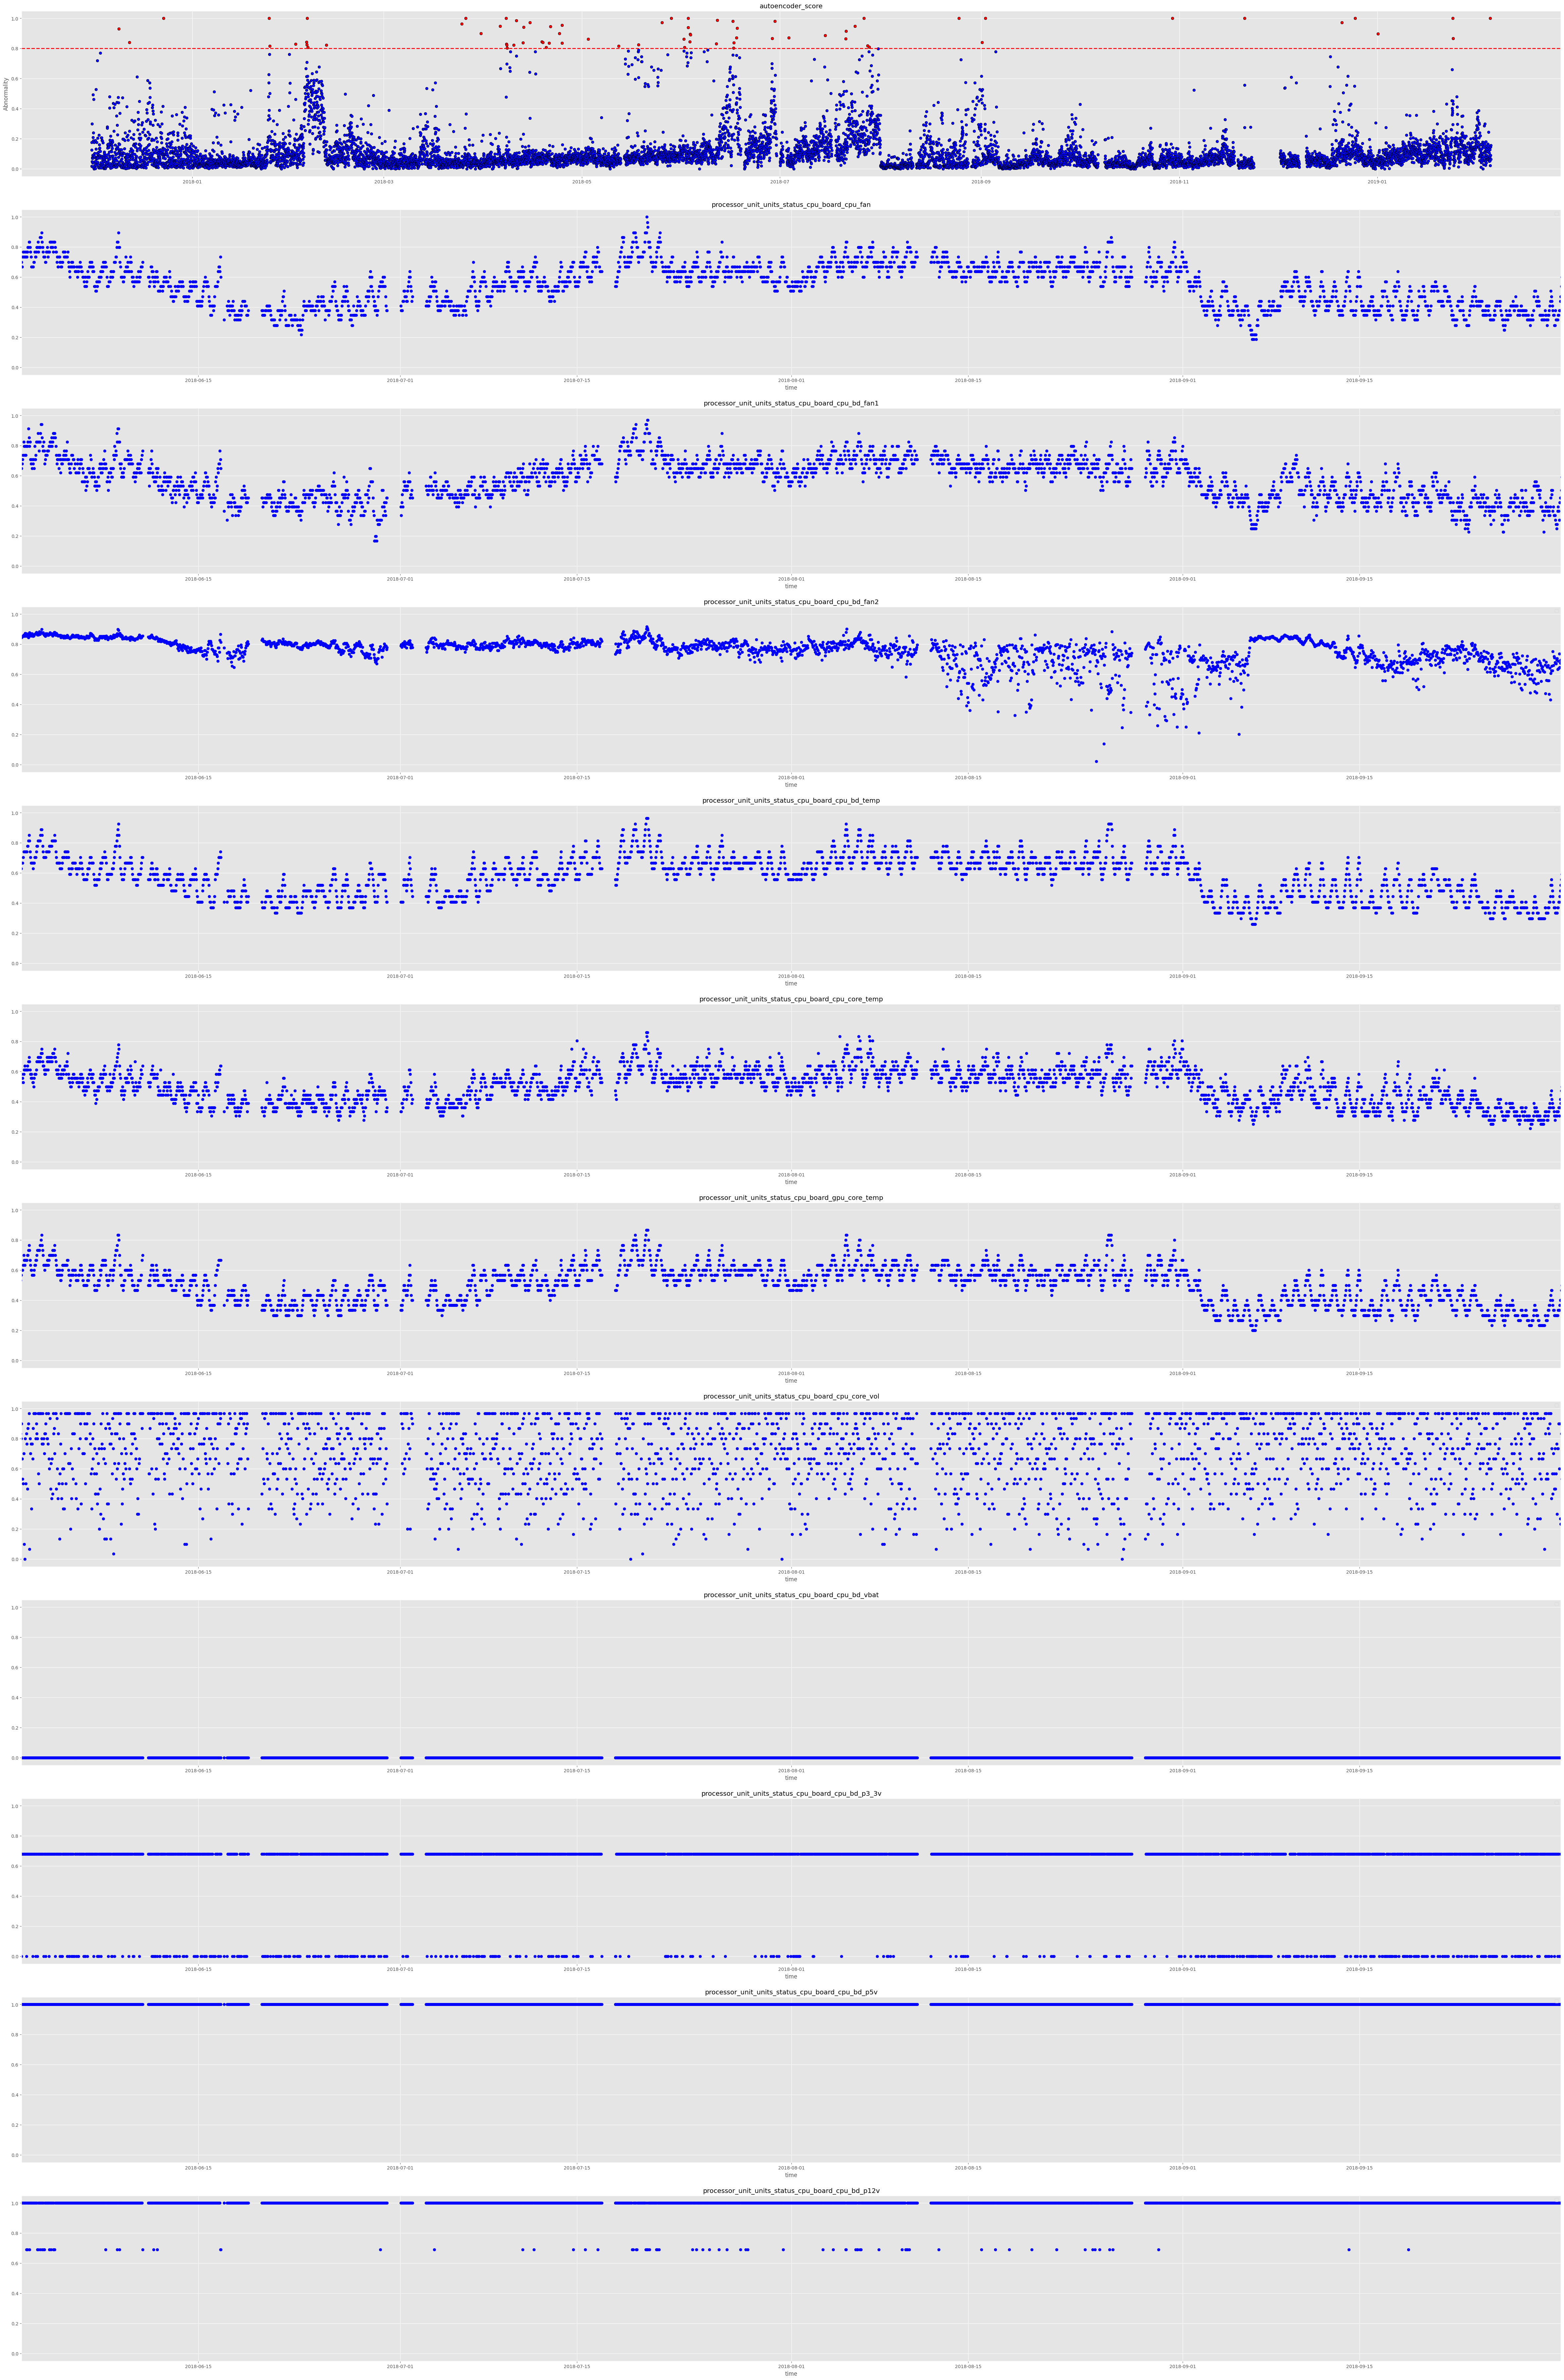

In [112]:
#散布図の作成

#異常スコアの出力
#図の大きさを指定
fig = plt.figure(figsize=(60,100))

#はじめのサブプロットの作成（異常スコア）
ax1 = fig.add_subplot(13,1,1)
ax1.set_title("autoencoder_score")
#正常スコアと異常スコア
ax1.scatter(results_df["measurement_date"], results_df["anomaly_score"], c='blue', marker='o', edgecolor='k')
ax1.scatter(abnormal_df["measurement_date"], abnormal_df["anomaly_score"], c='red', marker='o', edgecolor='k')
ax1.set_ylabel('Abnormality')
# ラベルの設定
ax1.set_ylabel('Abnormality')
# y=0.8の位置に赤い横線を引く
ax1.axhline(y=0.8, color='red', linestyle='--', linewidth=2)

# 元の特徴量の時系列ごとのデータ
for i, column in enumerate (colums_list):
    ax = fig.add_subplot(13,1,i+2)
    ax.scatter(data_ex["measurement_date"],data_ex[column], color='b')
    ax.set_xlabel('time')
    ax.set_title(column)
    ax.set_xlim(time.min(),time.max())
    ax.legend()
